In [1]:
from google.colab import userdata
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USERNAME = "affandymurad"
REPO_NAME = "Eksperimen_SML_Affandy-Murad"

!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
%cd {REPO_NAME}
!git config --global user.email "affandymurad@gmail.com"
!git config --global user.name "Affandy Murad"
!mkdir -p namadataset_raw preprocessing/namadataset_preprocessing

Cloning into 'Eksperimen_SML_Affandy-Murad'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Eksperimen_SML_Affandy-Murad


# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset: Telco Customer Churn (IBM Sample Data), diperoleh dari GitHub IBM (data pelanggan sebuah perusahaan telekomunikasi fiktif, tujuan: memprediksi pelanggan yang akan berhenti berlangganan/churn).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# simpan salinan mentah ke folder raw sesuai struktur repo
df.to_csv("namadataset_raw/Telco-Customer-Churn.csv", index=False)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


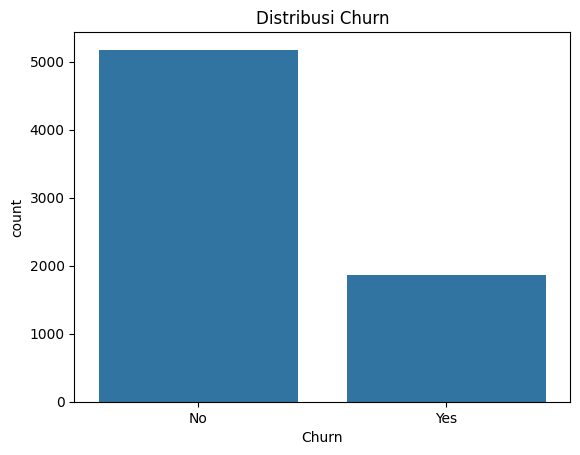

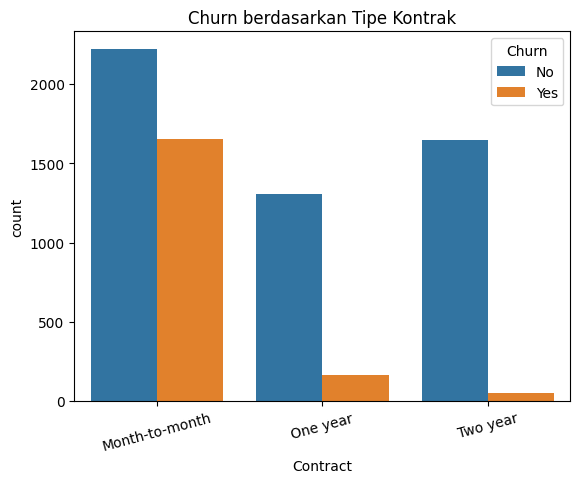

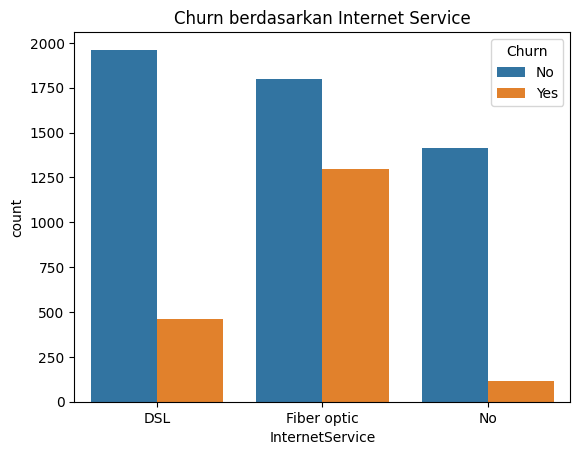

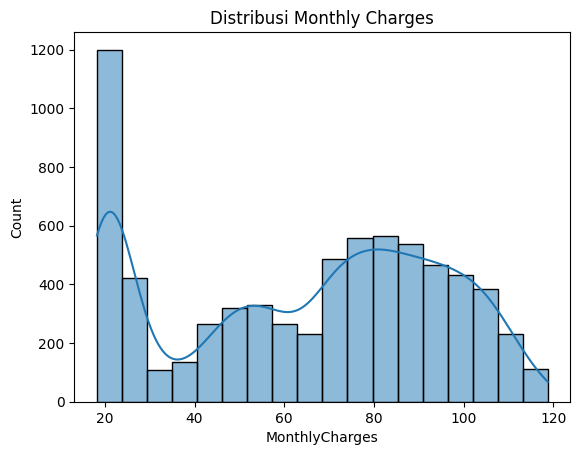

Jumlah data duplikat: 0
object
(11, 21)


In [4]:
df.info()
df.describe()
df.isnull().sum()

# Distribusi target (Churn)
sns.countplot(x="Churn", data=df)
plt.title("Distribusi Churn")
plt.show()

# Churn berdasarkan tipe kontrak
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn berdasarkan Tipe Kontrak")
plt.xticks(rotation=15)
plt.show()

# Churn berdasarkan jenis layanan internet
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn berdasarkan Internet Service")
plt.show()

# Distribusi biaya bulanan
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribusi Monthly Charges")
plt.show()

# Cek duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

# Cek tipe data TotalCharges (sering ke-load sebagai teks)
print(df["TotalCharges"].dtype)
print(df[df["TotalCharges"] == " "].shape)  # baris dengan spasi kosong

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# 1. Drop kolom yang tidak relevan sebagai fitur
df = df.drop(columns=["customerID"])

# 2. Perbaiki TotalCharges (ada baris berisi spasi kosong, bukan NaN asli)
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# 3. Hapus duplikat
df = df.drop_duplicates()

# 4. Tangani missing value
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 5. Encoding kolom kategorikal (termasuk target Churn: Yes/No -> 1/0)
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# 6. Pisahkan fitur dan target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# 7. Standarisasi fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 8. Split data train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Simpan hasil preprocessing
pd.DataFrame(X_train, columns=X.columns).to_csv("preprocessing/namadataset_preprocessing/X_train.csv", index=False)
pd.DataFrame(X_test, columns=X.columns).to_csv("preprocessing/namadataset_preprocessing/X_test.csv", index=False)
y_train.to_csv("preprocessing/namadataset_preprocessing/y_train.csv", index=False)
y_test.to_csv("preprocessing/namadataset_preprocessing/y_test.csv", index=False)

print("Preprocessing selesai. Jumlah data train:", X_train.shape[0], "| test:", X_test.shape[0])

Preprocessing selesai. Jumlah data train: 5616 | test: 1405


Buat **automate_Affandy-Murad.py**

In [6]:
%%writefile preprocessing/automate_Affandy-Murad.py
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import os

def preprocess_data(input_path, output_dir):
    df = pd.read_csv(input_path)

    df = df.drop(columns=["customerID"])
    df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
    df = df.drop_duplicates()
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

    le = LabelEncoder()
    for col in df.select_dtypes(include="object").columns:
        df[col] = le.fit_transform(df[col])

    X = df.drop(columns=["Churn"])
    y = df["Churn"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    os.makedirs(output_dir, exist_ok=True)
    pd.DataFrame(X_train, columns=X.columns).to_csv(f"{output_dir}/X_train.csv", index=False)
    pd.DataFrame(X_test, columns=X.columns).to_csv(f"{output_dir}/X_test.csv", index=False)
    y_train.to_csv(f"{output_dir}/y_train.csv", index=False)
    y_test.to_csv(f"{output_dir}/y_test.csv", index=False)
    print("Preprocessing selesai. Data tersimpan di", output_dir)

if __name__ == "__main__":
    preprocess_data(
        input_path="namadataset_raw/Telco-Customer-Churn.csv",
        output_dir="preprocessing/namadataset_preprocessing"
    )

Writing preprocessing/automate_Affandy-Murad.py


Test jalan:

In [7]:
!python preprocessing/automate_Affandy-Murad.py

Preprocessing selesai. Data tersimpan di preprocessing/namadataset_preprocessing


**Buat GitHub Actions workflow**

In [10]:
import os

os.makedirs(".github/workflows", exist_ok=True)

workflow_content = '''name: Automated Data Preprocessing

on:
  push:
    branches: [ main ]
  workflow_dispatch:

jobs:
  preprocess:
    runs-on: ubuntu-latest
    steps:
      - name: Checkout repo
        uses: actions/checkout@v3

      - name: Set up Python 3.12.7
        uses: actions/setup-python@v4
        with:
          python-version: "3.12.7"

      - name: Install dependencies
        run: pip install pandas numpy scikit-learn

      - name: Run preprocessing script
        run: python preprocessing/automate_Affandy-Murad.py

      - name: Commit updated dataset
        run: |
          git config --global user.name "github-actions"
          git config --global user.email "actions@github.com"
          git add preprocessing/namadataset_preprocessing/*
          git commit -m "Automated preprocessing update [skip ci]" || echo "No changes"
          git push
'''

with open(".github/workflows/preprocessing.yml", "w") as f:
    f.write(workflow_content)

print("File berhasil dibuat di .github/workflows/preprocessing.yml")

File berhasil dibuat di .github/workflows/preprocessing.yml
